In [42]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import accuracy_score

In [43]:
# Loading Data
df = pd.read_csv("globalwebtraffic.csv")

In [44]:
median_val = df['stickiness_index'].median()
df['retention_status'] = df['stickiness_index'].apply(lambda x: 'High Retention' if x >= median_val else 'Low Retention')


In [45]:
df['log_monthly_visits'] = np.log1p(df['monthly_visits'])
df['log_avg_session_duration_s'] = np.log1p(df['avg_session_duration_s'])

In [46]:
#(we are using the monthly_visits as an input to predict the retention.)
numeric_features = ['bounce_rate_pct', 'log_avg_session_duration_s', 'log_monthly_visits']
categorical_features = ['category', 'primary_market']

In [47]:
X = df[numeric_features + categorical_features]
y = df['retention_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [48]:
#Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])

Learning curves saved: learning_curves.png


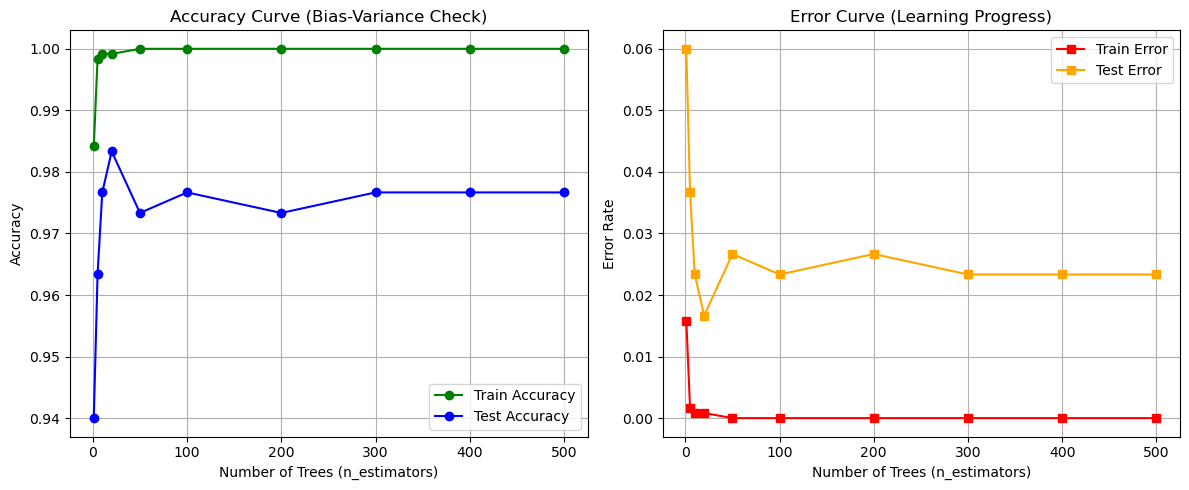

In [ ]:

n_estimators_range = [1, 5, 10, 20, 50, 100, 200, 300, 400, 500]
train_accuracy = []
test_accuracy = []

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

for n in n_estimators_range:
    clf = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    clf.fit(X_train_pre, y_train)
    
    # Accuracy tracking
    train_accuracy.append(accuracy_score(y_train, clf.predict(X_train_pre)))
    test_accuracy.append(accuracy_score(y_test, clf.predict(X_test_pre)))

# 6. Generatinf accuracy and loss curves
# In RandomForest, "loss" is 1 - accuracy, so 
train_error = [1 - acc for acc in train_accuracy]
test_error = [1 - acc for acc in test_accuracy]

plt.figure(figsize=(12, 5))

# for Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(n_estimators_range, train_accuracy, label='Train Accuracy', marker='o', color='green')
plt.plot(n_estimators_range, test_accuracy, label='Test Accuracy', marker='o', color='blue')
plt.title('Accuracy Curve (Bias-Variance Check)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# for Loss Curve
plt.subplot(1, 2, 2)
plt.plot(n_estimators_range, train_error, label='Train Error', marker='s', color='red')
plt.plot(n_estimators_range, test_error, label='Test Error', marker='s', color='orange')
plt.title('Error Curve (Learning Progress)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('learning_curves.png')
print("Learning curves saved: learning_curves.png")

In [52]:
# Grid Search for Maximizing Accuracy
param_grid = {
    'rf__n_estimators': [200, 500],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_leaf': [2, 5]
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print(" Training the User Retention Ai model")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
acc = accuracy_score(y_test, best_model.predict(X_test))




 Training the User Retention Ai model


In [56]:

#saving the Metadata
model_metadata = {
    'pipeline': best_model,
    'categories': df['category'].dropna().unique().tolist(),
    'markets': df['primary_market'].dropna().unique().tolist(),
    'median_stickiness': median_val
}

with open('retention_model.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)
print(f" Model Ready! Accuracy: {acc:.2%}")
print(classification_report(y_test, best_model.predict(X_test)))


 Model Ready! Accuracy: 97.67%
                precision    recall  f1-score   support

High Retention       0.98      0.97      0.98       145
 Low Retention       0.97      0.98      0.98       155

      accuracy                           0.98       300
     macro avg       0.98      0.98      0.98       300
  weighted avg       0.98      0.98      0.98       300



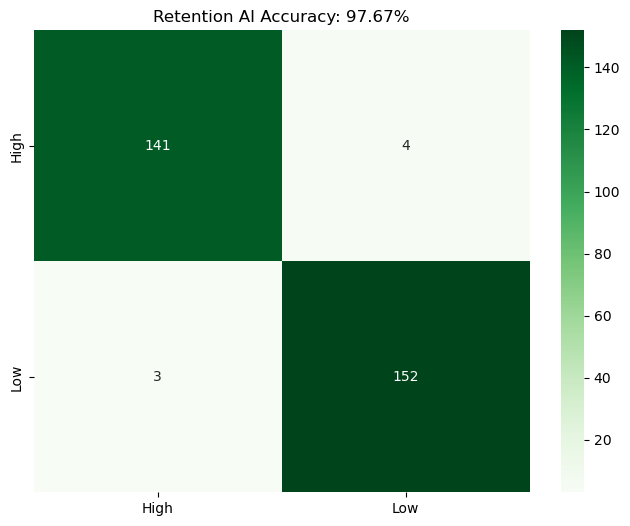

In [53]:

# Visualization
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['High', 'Low'], yticklabels=['High', 'Low'])
plt.title(f'Retention AI Accuracy: {acc:.2%}')
plt.savefig('model_performance.png')